In [198]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn import svm
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.wrappers.scikit_learn import KerasClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import joblib
from sklearn.metrics import confusion_matrix, plot_confusion_matrix, ConfusionMatrixDisplay, plot_roc_curve, RocCurveDisplay, roc_auc_score, classification_report,auc,roc_curve
from matplotlib.colors import ListedColormap
import sklearn.model_selection as model_selection
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings("ignore")

In [49]:
d=pd.read_csv("./Tests/ScaledFallSimulation.csv")

In [50]:
d.head()

,VelInc_X,VelInc_Y,VelInc_Z,OriInc_w,OriInc_x,OriInc_y,OriInc_z,Acc_X,Acc_Y,Acc_Z,...,Mag_X,Mag_Y,Mag_Z,Pressure,Roll,Pitch,Yaw,Sensor,Activity Type,Activity Number
0,-1.576812,-0.861107,0.157613,-0.012624,0.070376,0.041586,-1.130151,-1.602337,-0.870514,-0.012624,...,0.545317,0.027987,0.951742,-1.003680,1.197579,1.421885,-0.810281,2.0,0.0,801
1,-1.579566,-0.867024,0.157613,0.009643,0.055411,0.033629,-1.130366,-1.605135,-0.876495,0.009597,...,0.547768,0.027633,0.931559,-1.003465,1.198731,1.421288,-0.810281,2.0,0.0,801
2,-1.578918,-0.861443,0.157613,0.038875,0.065345,0.014602,-1.133662,-1.604476,-0.870854,0.038767,...,0.547768,0.023384,0.941650,-1.002929,1.199222,1.420689,-0.810281,2.0,0.0,801
3,-1.582809,-0.848994,0.157613,0.050906,0.042080,0.030862,-1.142528,-1.608430,-0.858271,0.050772,...,0.547768,0.023738,0.951742,-1.002260,1.200393,1.420211,-0.910945,2.0,0.0,801
4,-1.578316,-0.840610,0.157613,0.042252,0.048243,0.030862,-1.137759,-1.603865,-0.849795,0.042137,...,0.547768,0.031528,0.951742,-1.001684,1.201521,1.419684,-0.910945,2.0,0.0,801


In [51]:
d.columns

Index(['VelInc_X', 'VelInc_Y', 'VelInc_Z', 'OriInc_w', 'OriInc_x', 'OriInc_y',
       'OriInc_z', 'Acc_X', 'Acc_Y', 'Acc_Z', 'Gyr_X', 'Gyr_Y', 'Gyr_Z',
       'Mag_X', 'Mag_Y', 'Mag_Z', 'Pressure', 'Roll', 'Pitch', 'Yaw', 'Sensor',
       'Activity Type', 'Activity Number'],
      dtype='object')

In [52]:
d.shape

(9468875, 23)

In [63]:
df = d.sample(n=30000, random_state=42)

In [54]:
#df.to_csv('your_new_file.csv', index=False)


In [55]:
df.shape

(30000, 23)

In [258]:
val=d.sample(n=10, random_state=92)

In [259]:
X_val=val.iloc[:,:-3]

In [58]:
X=df.iloc[:,:-3]
y=df['Activity Type']

In [59]:
y.unique()

array([0., 1.])

In [60]:
X.describe()

,VelInc_X,VelInc_Y,VelInc_Z,OriInc_w,OriInc_x,OriInc_y,OriInc_z,Acc_X,Acc_Y,Acc_Z,Gyr_X,Gyr_Y,Gyr_Z,Mag_X,Mag_Y,Mag_Z,Pressure,Roll,Pitch,Yaw
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,0.002661,0.000589,-0.004677,0.003392,-0.005176,0.005650,-0.001697,0.002522,0.000447,0.003394,-0.005193,0.005645,-0.000367,0.003125,-0.002691,0.000766,-0.003969,-0.000485,-0.002592,0.004208
std,0.944268,0.930700,1.037192,1.038176,0.980910,1.014220,0.969632,0.959261,0.940650,1.038312,0.981135,1.014232,1.004427,0.986918,1.000019,0.996604,0.998322,1.001106,1.002815,1.003443
min,-10.245038,-11.275902,-55.973304,-28.985882,-28.967757,-16.048557,-11.865910,-10.410079,-11.398098,-29.345218,-29.377519,-16.125349,-3.410752,-6.832820,-3.390654,-2.031885,-1.752330,-1.126237,-1.705237,-2.722903
25%,-0.322441,-0.450227,0.154159,-0.046817,-0.031613,-0.029334,-0.954055,-0.327776,-0.455185,-0.046744,-0.031560,-0.029330,-0.595095,-0.419254,-0.786485,-0.740213,-0.822038,-0.861964,-0.935081,-0.608952
50%,0.160863,-0.052189,0.157613,-0.013891,-0.004953,-0.011777,0.581309,0.163307,-0.052836,-0.013887,-0.004943,-0.011801,-0.286098,0.148559,-0.104439,0.077172,-0.037543,-0.517690,-0.088295,-0.004966
75%,0.410087,0.483291,0.157613,0.017769,0.026109,0.006645,0.725271,0.416542,0.488442,0.017705,0.026068,0.006591,0.321376,0.615467,0.765182,0.706190,0.612000,1.069554,0.817186,0.699684
max,7.417773,16.099939,0.158765,26.425977,25.448105,19.174221,9.731722,7.537018,16.274213,26.634197,25.569543,19.320220,8.500262,2.590375,6.514377,1.822947,2.058434,3.510183,1.782420,3.316957


### Splitting the data to test and train

In [61]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=0, train_size=0.70) 

## Hypertuning

In [62]:
svm_model = SVC(kernel='linear')
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'gamma': ['scale', 'auto']
}
grid_search = GridSearchCV(estimator=svm_model, param_grid=param_grid)
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
best_model = SVC(**best_params)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

svm_accuracy = accuracy_score(y_test, y_pred)
svm_f1 = f1_score(y_test, y_pred)
svm_precision = precision_score(y_test, y_pred)
svm_recall = recall_score(y_test, y_pred)
svm_auc_roc = roc_auc_score(y_test, y_pred)

print('Best hyperparameters:', best_params)
print('Accuracy:', svm_accuracy)
print('F1 score:', svm_f1)
print('Precision:', svm_precision)
print('Recall:', svm_recall)
print('AUC-ROC:', svm_auc_roc)

Best hyperparameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Accuracy: 0.8157777777777778
F1 score: 0.8356788899900891
Precision: 0.788627010849233
Recall: 0.8887015177065767
AUC-ROC: 0.8115969994547921


In [67]:
rf_model = RandomForestClassifier(random_state=0)
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_search = GridSearchCV(rf_model, param_grid=param_grid, n_jobs=-1)
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
best_rf_model = grid_search.best_estimator_
y_pred = best_rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred)
rf_f1 = f1_score(y_test, y_pred)
rf_precision = precision_score(y_test, y_pred)
rf_recall = recall_score(y_test, y_pred)
rf_auc_roc = roc_auc_score(y_test, y_pred)

print('Best hyperparameters:', best_params)
print('Accuracy:', rf_accuracy)
print('F1 score:', rf_f1)
print('Precision:', rf_precision)
print('Recall:', rf_recall)
print('AUC-ROC:', rf_auc_roc)

Best hyperparameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 150}
Accuracy: 0.9152222222222223
F1 score: 0.9208752462926475
Precision: 0.906307409675444
Recall: 0.9359190556492412
AUC-ROC: 0.9140356556441694


In [71]:
def create_model(optimizer='adam', activation='relu'):
    model = tf.keras.models.Sequential([
        tf.keras.layers.Dense(64, activation=activation, input_shape=(X_train.shape[1],)),
        tf.keras.layers.Dense(32, activation=activation),
        tf.keras.layers.Dense(1, activation='tanh')
    ])
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model


nn_classifier = KerasClassifier(build_fn=create_model, epochs=10, batch_size=32, validation_split=0.2)
param_grid = {
    'optimizer': ['adam', 'sgd'],
    'activation': ['relu', 'tanh', 'sigmoid']
}
grid_search = GridSearchCV(estimator=nn_classifier, param_grid=param_grid)
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
nn_model = create_model(optimizer=best_params['optimizer'], activation=best_params['activation'])
nn_model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)
y_pred = nn_model.predict(X_test)
y_pred_discrete = (y_pred > 0.5).astype(int)

nn_accuracy = accuracy_score(y_test, y_pred_discrete)
nn_f1 = f1_score(y_test, y_pred_discrete)
nn_precision = precision_score(y_test, y_pred_discrete)
nn_recall = recall_score(y_test, y_pred_discrete)
nn_auc_roc = roc_auc_score(y_test, y_pred)

print('Best hyperparameters:', best_params)
print('Accuracy:', nn_accuracy)
print('F1 score:', nn_f1)
print('Precision:', nn_precision)
print('Recall:', nn_recall)
print('AUC-ROC:', nn_auc_roc)

Epoch 1/10
420/420 [==============================] - 0s 642us/step - loss: 0.8818 - accuracy: 0.6163 - val_loss: 0.6447 - val_accuracy: 0.6360
Epoch 2/10
420/420 [==============================] - 0s 502us/step - loss: 0.6184 - accuracy: 0.6684 - val_loss: 0.6266 - val_accuracy: 0.6774
Epoch 3/10
420/420 [==============================] - 0s 492us/step - loss: 0.5871 - accuracy: 0.7031 - val_loss: 0.6255 - val_accuracy: 0.6699
Epoch 4/10
420/420 [==============================] - 0s 506us/step - loss: 0.5806 - accuracy: 0.7171 - val_loss: 0.6430 - val_accuracy: 0.6926
Epoch 5/10
420/420 [==============================] - 0s 521us/step - loss: 0.5657 - accuracy: 0.7277 - val_loss: 0.5986 - val_accuracy: 0.7077
Epoch 6/10
420/420 [==============================] - 0s 516us/step - loss: 0.5581 - accuracy: 0.7308 - val_loss: 0.6182 - val_accuracy: 0.7301
Epoch 7/10
420/420 [==============================] - 0s 505us/step - loss: 0.6118 - accuracy: 0.7091 - val_loss: 0.6196 - val_accuracy:

Epoch 5/10
420/420 [==============================] - 0s 415us/step - loss: 0.5808 - accuracy: 0.7019 - val_loss: 0.5956 - val_accuracy: 0.6872
Epoch 6/10
420/420 [==============================] - 0s 413us/step - loss: 0.5673 - accuracy: 0.7076 - val_loss: 0.5933 - val_accuracy: 0.6914
Epoch 7/10
420/420 [==============================] - 0s 421us/step - loss: 0.8668 - accuracy: 0.6988 - val_loss: 1.3320 - val_accuracy: 0.6146
Epoch 8/10
420/420 [==============================] - 0s 430us/step - loss: 1.9844 - accuracy: 0.6045 - val_loss: 1.3150 - val_accuracy: 0.5756
Epoch 9/10
420/420 [==============================] - 0s 430us/step - loss: 1.5017 - accuracy: 0.6051 - val_loss: 1.9242 - val_accuracy: 0.5318
Epoch 10/10
132/132 [==============================] - 0s 353us/step - loss: 0.8290 - accuracy: 0.6481
Epoch 1/10
420/420 [==============================] - 0s 565us/step - loss: 0.6528 - accuracy: 0.6250 - val_loss: 0.6552 - val_accuracy: 0.6387
Epoch 2/10
420/420 [=============

Epoch 9/10
420/420 [==============================] - 0s 500us/step - loss: 0.5703 - accuracy: 0.6975 - val_loss: 0.5940 - val_accuracy: 0.6780
Epoch 10/10
132/132 [==============================] - 0s 344us/step - loss: 0.5917 - accuracy: 0.6971
Epoch 1/10
420/420 [==============================] - 0s 626us/step - loss: 1.0821 - accuracy: 0.6084 - val_loss: 0.6699 - val_accuracy: 0.6125
Epoch 2/10
420/420 [==============================] - 0s 500us/step - loss: 0.7270 - accuracy: 0.6245 - val_loss: 0.6491 - val_accuracy: 0.6057
Epoch 3/10
420/420 [==============================] - 0s 506us/step - loss: 0.6222 - accuracy: 0.6447 - val_loss: 0.6230 - val_accuracy: 0.6393
Epoch 4/10
420/420 [==============================] - 0s 500us/step - loss: 0.6511 - accuracy: 0.6629 - val_loss: 0.8411 - val_accuracy: 0.6304
Epoch 5/10
420/420 [==============================] - 0s 495us/step - loss: 0.6221 - accuracy: 0.6675 - val_loss: 0.6174 - val_accuracy: 0.6619
Epoch 6/10
420/420 [=============

420/420 [==============================] - 0s 429us/step - loss: 0.6285 - accuracy: 0.6435 - val_loss: 0.6354 - val_accuracy: 0.6345
Epoch 3/10
420/420 [==============================] - 0s 425us/step - loss: 0.6158 - accuracy: 0.6617 - val_loss: 0.6276 - val_accuracy: 0.6565
Epoch 4/10
420/420 [==============================] - 0s 427us/step - loss: 0.6134 - accuracy: 0.6651 - val_loss: 0.6270 - val_accuracy: 0.6539
Epoch 5/10
420/420 [==============================] - 0s 440us/step - loss: 0.6061 - accuracy: 0.6764 - val_loss: 0.6224 - val_accuracy: 0.6622
Epoch 6/10
420/420 [==============================] - 0s 428us/step - loss: 0.5989 - accuracy: 0.6815 - val_loss: 0.6214 - val_accuracy: 0.6667
Epoch 7/10
420/420 [==============================] - 0s 425us/step - loss: 0.9460 - accuracy: 0.6504 - val_loss: 1.9420 - val_accuracy: 0.5574
Epoch 8/10
420/420 [==============================] - 0s 433us/step - loss: 1.1289 - accuracy: 0.5905 - val_loss: 0.6450 - val_accuracy: 0.6173
Epo

Epoch 6/10
420/420 [==============================] - 0s 514us/step - loss: 0.6275 - accuracy: 0.6394 - val_loss: 0.6474 - val_accuracy: 0.6235
Epoch 7/10
420/420 [==============================] - 0s 515us/step - loss: 0.6252 - accuracy: 0.6389 - val_loss: 0.6448 - val_accuracy: 0.6232
Epoch 8/10
420/420 [==============================] - 0s 516us/step - loss: 0.6226 - accuracy: 0.6394 - val_loss: 0.6403 - val_accuracy: 0.6307
Epoch 9/10
420/420 [==============================] - 0s 510us/step - loss: 0.6151 - accuracy: 0.6466 - val_loss: 0.6343 - val_accuracy: 0.6348
Epoch 10/10
132/132 [==============================] - 0s 350us/step - loss: 0.6241 - accuracy: 0.6505
Epoch 1/10
420/420 [==============================] - 0s 630us/step - loss: 8.2358 - accuracy: 0.4661 - val_loss: 7.9833 - val_accuracy: 0.4824
Epoch 2/10
420/420 [==============================] - 0s 518us/step - loss: 8.2358 - accuracy: 0.4661 - val_loss: 7.9833 - val_accuracy: 0.4824
Epoch 3/10
420/420 [=============

Epoch 10/10
132/132 [==============================] - 0s 366us/step - loss: 0.6367 - accuracy: 0.6250
Epoch 1/10
420/420 [==============================] - 0s 584us/step - loss: 0.6758 - accuracy: 0.5778 - val_loss: 0.6680 - val_accuracy: 0.6071
Epoch 2/10
420/420 [==============================] - 0s 484us/step - loss: 0.6575 - accuracy: 0.6166 - val_loss: 0.6562 - val_accuracy: 0.6190
Epoch 3/10
420/420 [==============================] - 0s 488us/step - loss: 0.6449 - accuracy: 0.6272 - val_loss: 0.6502 - val_accuracy: 0.6164
Epoch 4/10
420/420 [==============================] - 0s 436us/step - loss: 0.6381 - accuracy: 0.6292 - val_loss: 0.6555 - val_accuracy: 0.6104
Epoch 5/10
420/420 [==============================] - 0s 426us/step - loss: 0.6345 - accuracy: 0.6297 - val_loss: 0.6451 - val_accuracy: 0.6208
Epoch 6/10
420/420 [==============================] - 0s 419us/step - loss: 0.6338 - accuracy: 0.6302 - val_loss: 0.6500 - val_accuracy: 0.6074
Epoch 7/10
420/420 [=============

In [82]:
max_n_neighbours = 10

param_grid = {
    'n_neighbors': range(1, max_n_neighbours),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
knn_model = KNeighborsClassifier()
grid_search = GridSearchCV(knn_model, param_grid, cv=5)
grid_search.fit(X_train, y_train)
best_knn_model = KNeighborsClassifier(**grid_search.best_params_)
best_knn_model.fit(X_train, y_train)
y_pred = best_knn_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, y_pred)

print("Best score:", grid_search.best_score_)
print("Best hyperparameters:", grid_search.best_params_)
print('Accuracy:', accuracy)
print('F1 score:', f1)
print('Precision:', precision)
print('Recall:', recall)
print('AUC-ROC:', auc_roc)

Best score: 0.9013809523809524
Best hyperparameters: {'metric': 'manhattan', 'n_neighbors': 1, 'weights': 'uniform'}
Accuracy: 0.9022222222222223
F1 score: 0.9080459770114943
Precision: 0.9003315375051802
Recall: 0.915893760539629
AUC-ROC: 0.901438421623198


In [75]:
param_grid = {
    'max_depth': [3, 5, 7, None],
    'max_features': ['sqrt', 'log2', None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}
grid_search = GridSearchCV(estimator=DecisionTreeClassifier(random_state=0),param_grid=param_grid,n_jobs=-1)
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
dt_model = DecisionTreeClassifier(random_state=0, **best_params)
dt_model.fit(X_train, y_train)
y_pred = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred)
dt_f1 = f1_score(y_test, y_pred)
dt_precision = precision_score(y_test, y_pred)
dt_recall = recall_score(y_test, y_pred)
dt_auc_roc = roc_auc_score(y_test, y_pred)

print("Best hyperparameters:", best_params)
print('Accuracy:', dt_accuracy)
print('F1 score:', dt_f1)
print('Precision:', dt_precision)
print('Recall:', dt_recall)
print('AUC-ROC:', dt_auc_roc)

Best hyperparameters: {'criterion': 'entropy', 'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Accuracy: 0.8607777777777778
F1 score: 0.8677572559366755
Precision: 0.8689494821390826
Recall: 0.8665682967959528
AUC-ROC: 0.8604458025333147


In [115]:
param_grid = {'n_estimators': [50, 100, 150], 
              'max_depth': [None, 5, 7]}
gb_model = GradientBoostingClassifier()
grid_search = GridSearchCV(gb_model, param_grid)
grid_search.fit(X_train, y_train)
best_gb_model = grid_search.best_estimator_
y_pred = best_gb_model.predict(X_test)

gb_accuracy = accuracy_score(y_test, y_pred)
gb_f1 = f1_score(y_test, y_pred)
gb_precision = precision_score(y_test, y_pred)
gb_recall = recall_score(y_test, y_pred)
gb_auc_roc = roc_auc_score(y_test, y_pred)

print("Best hyperparameters:", grid_search.best_params_)
print('Accuracy:', gb_accuracy)
print('F1 score:', gb_f1)
print('Precision:', gb_precision)
print('Recall:', gb_recall)
print('AUC-ROC:', gb_auc_roc)

Best hyperparameters: {'max_depth': 7, 'n_estimators': 150}
Accuracy: 0.9147777777777778
F1 score: 0.9214058817501793
Precision: 0.8965104685942173
Recall: 0.9477234401349073
AUC-ROC: 0.9128889757065514


## Selecting 90k rows of data randomly to train the models

In [165]:
df1 = d.sample(n=99999, random_state=96)

In [166]:
X1=df1.iloc[:,:-3]
y1=df1['Activity Type']

In [167]:
X1.describe()

,VelInc_X,VelInc_Y,VelInc_Z,OriInc_w,OriInc_x,OriInc_y,OriInc_z,Acc_X,Acc_Y,Acc_Z,Gyr_X,Gyr_Y,Gyr_Z,Mag_X,Mag_Y,Mag_Z,Pressure,Roll,Pitch,Yaw
count,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000
mean,-0.000599,0.003595,-0.001893,-0.000790,0.004146,0.006146,-0.001047,-0.000761,0.003512,-0.000794,0.004150,0.006152,-0.001045,-0.003954,0.002704,-0.004112,-0.000866,0.000764,0.002265,-0.001130
std,0.960751,0.924749,0.999848,1.007090,1.013392,1.001644,0.967281,0.976021,0.934639,1.006860,1.013560,1.001724,1.004175,1.006533,0.999650,0.997437,0.995032,0.998891,1.002736,1.000196
min,-25.885765,-15.735508,-81.547446,-24.613289,-28.349537,-19.699236,-13.842472,-26.302546,-15.905999,-24.779577,-28.547418,-19.862441,-7.478374,-6.830860,-3.759959,-2.041976,-1.752330,-1.127637,-1.705269,-2.622239
25%,-0.319501,-0.447120,0.154159,-0.047239,-0.031236,-0.028988,-0.956050,-0.324789,-0.452031,-0.047165,-0.031184,-0.028985,-0.596264,-0.418274,-0.779669,-0.763759,-0.816773,-0.858021,-0.929600,-0.709616
50%,0.163881,-0.049168,0.157613,-0.013785,-0.004450,-0.011690,0.582488,0.166373,-0.049910,-0.013782,-0.004441,-0.011715,-0.290384,0.149049,-0.090629,0.070445,-0.029001,-0.515396,-0.076933,-0.004966
75%,0.412333,0.485307,0.157613,0.018243,0.027744,0.006991,0.724912,0.418817,0.490480,0.018127,0.027701,0.006936,0.328390,0.608789,0.773680,0.706190,0.614337,1.073122,0.825216,0.699684
max,11.783469,15.497464,0.158765,25.846609,27.265039,25.007696,12.618415,11.972980,15.665213,26.079700,27.683282,25.546501,8.410251,2.592580,6.783124,1.829675,2.058334,3.501699,1.782708,3.417622


In [168]:
X_train, X_test, y_train, y_test = train_test_split(X1, y1, test_size=0.30, random_state=1, train_size=0.70) 

## Training the models using the best parameters

### Support Vector Machine

In [169]:
svm_model = SVC(C=10, gamma='scale', kernel='rbf')
svm_model.fit(X_train, y_train)
y_pred = svm_model.predict(X_test)

svm_accuracy = accuracy_score(y_test, y_pred)
svm_f1 = f1_score(y_test, y_pred)
svm_precision = precision_score(y_test, y_pred)
svm_recall = recall_score(y_test, y_pred)
svm_auc_roc = roc_auc_score(y_test, y_pred)
print('Accuracy:', svm_accuracy)
print('F1 score:', svm_f1)
print('Precision:', svm_precision)
print('Recall:', svm_recall)
print('AUC-ROC:', svm_auc_roc)

Accuracy: 0.8453
F1 score: 0.8611933602512338
Precision: 0.8204353772509688
Recall: 0.9062126266758985
AUC-ROC: 0.8414716502613533


### Random Forest model

In [170]:
rf_model = RandomForestClassifier(max_depth= None, min_samples_leaf= 1, min_samples_split= 2, n_estimators=150)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred)
rf_f1 = f1_score(y_test, y_pred)
rf_precision = precision_score(y_test, y_pred)
rf_recall = recall_score(y_test, y_pred)
rf_auc_roc = roc_auc_score(y_test, y_pred)

print('Accuracy:', rf_accuracy)
print('F1 score:', rf_f1)
print('Precision:', rf_precision)
print('Recall:', rf_recall)
print('AUC-ROC:', rf_auc_roc)

Accuracy: 0.9584666666666667
F1 score: 0.960913482652613
Precision: 0.9577887561753486
Recall: 0.9640586643167369
AUC-ROC: 0.9581152104266317


### Neural Network Model

In [171]:
nn_model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='relu') # modified to output binary classification
])
nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = nn_model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)
y_pred = nn_model.predict(X_test)
y_pred_discrete = (y_pred > 0.5).astype(int)  # convert predictions to binary values

nn_accuracy = accuracy_score(y_test, y_pred_discrete)
nn_f1 = f1_score(y_test, y_pred_discrete)
nn_precision = precision_score(y_test, y_pred_discrete)
nn_recall = recall_score(y_test, y_pred_discrete)
nn_auc_roc = roc_auc_score(y_test, y_pred)

print('Accuracy:', nn_accuracy)
print('F1 score:', nn_f1)
print('Precision:', nn_precision)
print('Recall:', nn_recall)
print('AUC-ROC:', nn_auc_roc)

Epoch 1/10
1750/1750 [==============================] - 1s 515us/step - loss: 0.7999 - accuracy: 0.6182 - val_loss: 0.6641 - val_accuracy: 0.6634
Epoch 2/10
1750/1750 [==============================] - 1s 478us/step - loss: 0.7108 - accuracy: 0.6759 - val_loss: 0.8162 - val_accuracy: 0.6591
Epoch 3/10
1750/1750 [==============================] - 1s 481us/step - loss: 0.6336 - accuracy: 0.6937 - val_loss: 0.6729 - val_accuracy: 0.6426
Epoch 4/10
1750/1750 [==============================] - 1s 478us/step - loss: 0.6499 - accuracy: 0.6846 - val_loss: 0.6249 - val_accuracy: 0.6940
Epoch 5/10
1750/1750 [==============================] - 1s 479us/step - loss: 0.6229 - accuracy: 0.6983 - val_loss: 0.5910 - val_accuracy: 0.7192
Epoch 6/10
1750/1750 [==============================] - 1s 481us/step - loss: 0.5876 - accuracy: 0.7171 - val_loss: 0.5913 - val_accuracy: 0.7246
Epoch 7/10
1750/1750 [==============================] - 1s 486us/step - loss: 0.5702 - accuracy: 0.7258 - val_loss: 0.5820 -

### K-Nearest Neighbour

In [172]:
knn_model = KNeighborsClassifier(metric='manhattan',n_neighbors=1, weights='uniform')
knn_model.fit(X_train, y_train)
y_pred = knn_model.predict(X_test)

knn_accuracy = accuracy_score(y_test, y_pred)
knn_f1 = f1_score(y_test, y_pred)
knn_precision = precision_score(y_test, y_pred)
knn_recall = recall_score(y_test, y_pred)
knn_auc_roc = roc_auc_score(y_test, y_pred)

print('Accuracy:', knn_accuracy)
print('F1 score:', knn_f1)
print('Precision:', knn_precision)
print('Recall:', knn_recall)
print('AUC-ROC:', knn_auc_roc)

Accuracy: 0.9474666666666667
F1 score: 0.9504527162977867
Precision: 0.9494378493813203
Recall: 0.9514697551457166
AUC-ROC: 0.9472150731372315


## Decision Tree 

In [173]:
dt_model = DecisionTreeClassifier(criterion= 'entropy', max_depth= None, max_features= None, 
                                  min_samples_leaf=1, min_samples_split=2)
dt_model.fit(X_train, y_train)
y_pred = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred)
dt_f1 = f1_score(y_test, y_pred)
dt_precision = precision_score(y_test, y_pred)
dt_recall = recall_score(y_test, y_pred)
dt_auc_roc = roc_auc_score(y_test, y_pred)

print('Accuracy:', dt_accuracy)
print('F1 score:', dt_f1)
print('Precision:', dt_precision)
print('Recall:', dt_recall)
print('AUC-ROC:', dt_auc_roc)

Accuracy: 0.9243333333333333
F1 score: 0.9287105081339112
Precision: 0.9267314321529301
Recall: 0.9306980550135331
AUC-ROC: 0.9239333115002477


## Gradient Booster

In [174]:
gb_model = GradientBoostingClassifier(max_depth= 7, n_estimators=150)
gb_model.fit(X_train, y_train)
y_pred = gb_model.predict(X_test)

gb_accuracy = accuracy_score(y_test, y_pred)
gb_f1 = f1_score(y_test, y_pred)
gb_precision = precision_score(y_test, y_pred)
gb_recall = recall_score(y_test, y_pred)
gb_auc_roc = roc_auc_score(y_test, y_pred)

print('Accuracy:', gb_accuracy)
print('F1 score:', gb_f1)
print('Precision:', gb_precision)
print('Recall:', gb_recall)
print('AUC-ROC:', gb_auc_roc)

Accuracy: 0.9325666666666667
F1 score: 0.9376098689282961
Precision: 0.9191558834200024
Recall: 0.9568200415434003
AUC-ROC: 0.9310423455786159


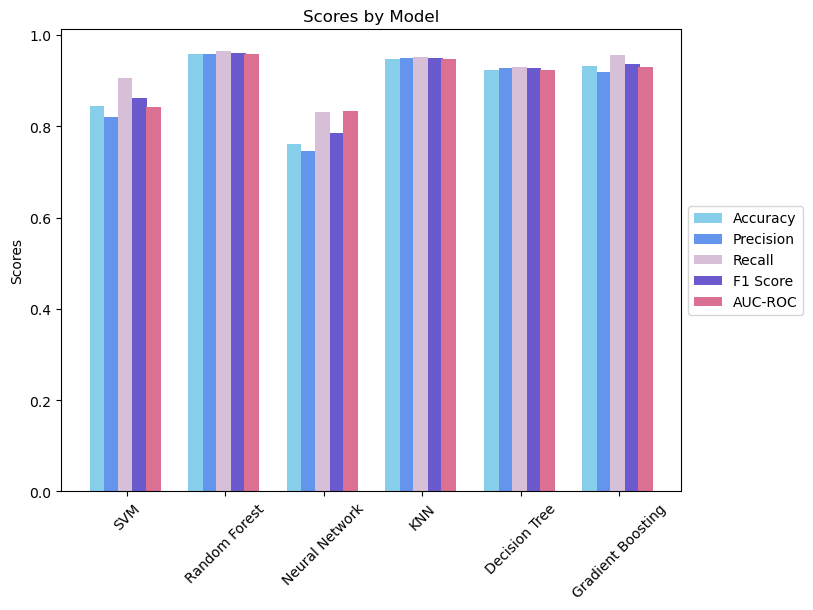

In [175]:
models = ['SVM', 'Random Forest', 'Neural Network', 'KNN', 'Decision Tree', 'Gradient Boosting']
accuracy = [svm_accuracy, rf_accuracy, nn_accuracy, knn_accuracy, dt_accuracy, gb_accuracy]
precision = [svm_precision, rf_precision, nn_precision, knn_precision, dt_precision, gb_precision]
recall = [svm_recall, rf_recall, nn_recall, knn_recall, dt_recall, gb_recall]
f1 = [svm_f1,rf_f1,nn_f1,knn_f1,dt_f1, gb_f1]
auc_roc=[svm_auc_roc, rf_auc_roc, nn_auc_roc, knn_auc_roc, dt_auc_roc, gb_auc_roc]

x = np.arange(len(models))
width = 0.15
fig, ax = plt.subplots(figsize=(8,6))
rects1 = ax.bar(x - 2.0*width, accuracy, width, label='Accuracy', color='skyblue')
rects2 = ax.bar(x - 1.0*width, precision, width, label='Precision',color='cornflowerblue')
rects3 = ax.bar(x - 0.1*width, recall, width, label='Recall', color='thistle')
rects4 = ax.bar(x + 0.9*width, f1, width, label='F1 Score', color='slateblue')
rects5 = ax.bar(x + 1.8*width, auc_roc, width, label='AUC-ROC', color='palevioletred')
ax.set_ylabel('Scores')
ax.set_title('Scores by Model')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.xticks(rotation=45)
plt.show()

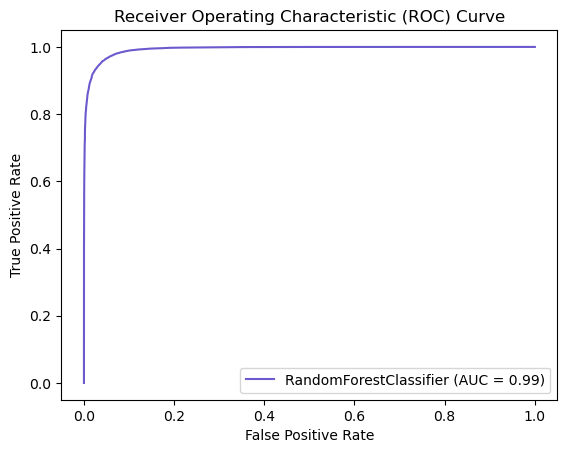

In [199]:
from sklearn.metrics import roc_curve, roc_auc_score

RocCurveDisplay.from_estimator(rf_model,X_test, y_test, color='slateblue')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.show()



938/938 [==============================] - 0s 272us/step


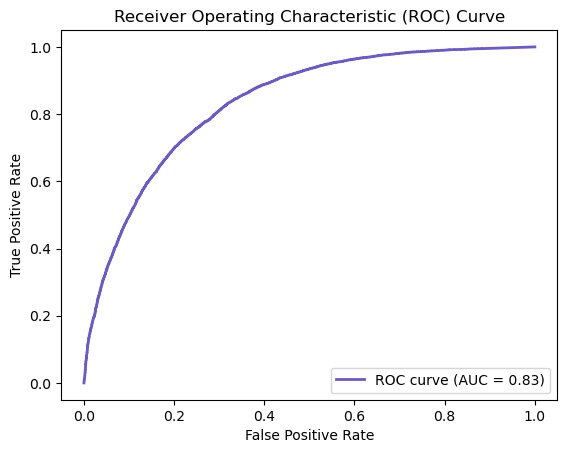

In [177]:
y_pred = nn_model.predict(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='slateblue', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

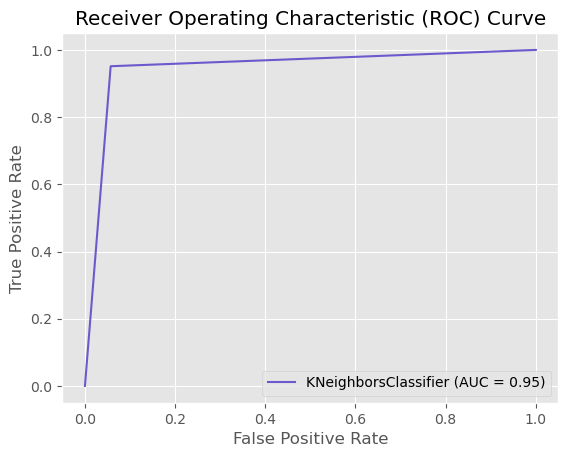

In [293]:
RocCurveDisplay.from_estimator(knn_model,X_test, y_test, color='slateblue') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.show()

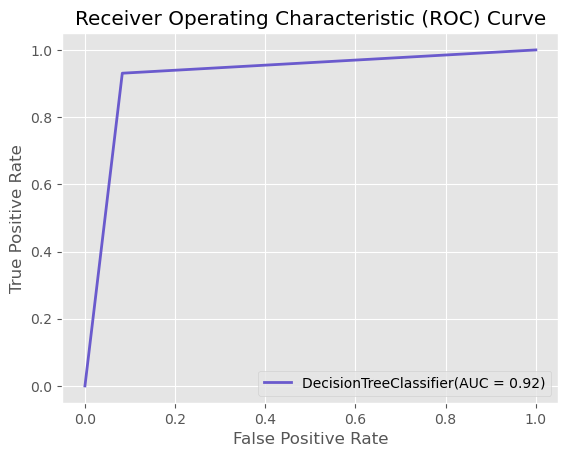

In [296]:
y_pred = dt_model.predict(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='slateblue', lw=2, label='DecisionTreeClassifier(AUC = %0.2f)' % roc_auc)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

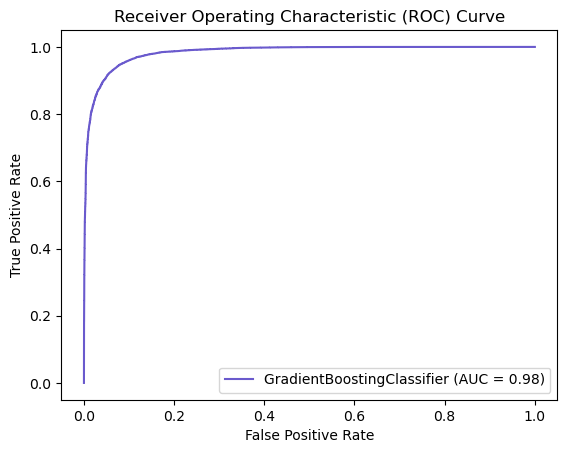

In [201]:
RocCurveDisplay.from_estimator(gb_model,X_test, y_test, color='slateblue')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.show()

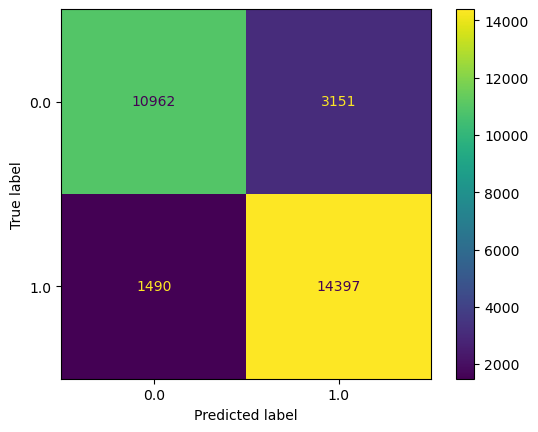

In [181]:
plot_confusion_matrix(svm_model,X_test, y_test) # Use `plot_confusion_matrix` to generate graphical output
plt.show()

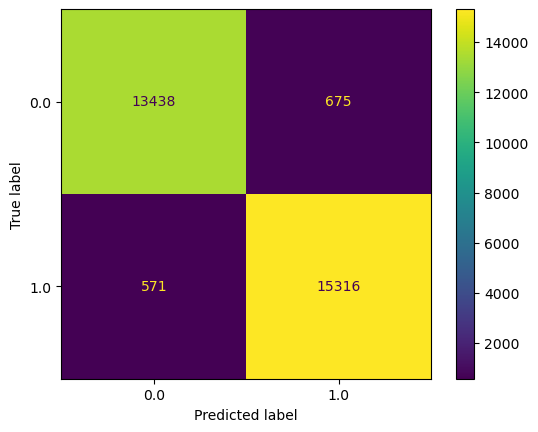

In [182]:
plot_confusion_matrix(rf_model,X_test, y_test) # Use `plot_confusion_matrix` to generate graphical output
plt.show()

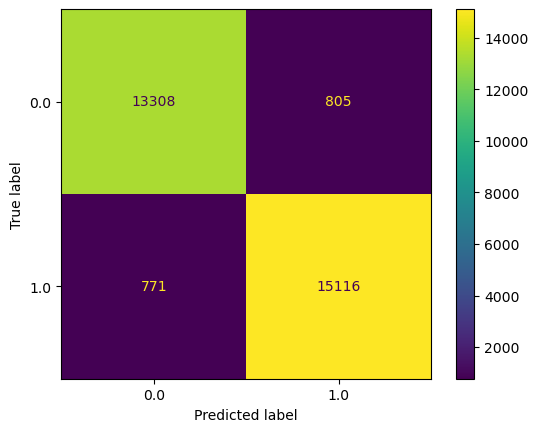

In [183]:
plot_confusion_matrix(knn_model,X_test, y_test) # Use `plot_confusion_matrix` to generate graphical output
plt.show()

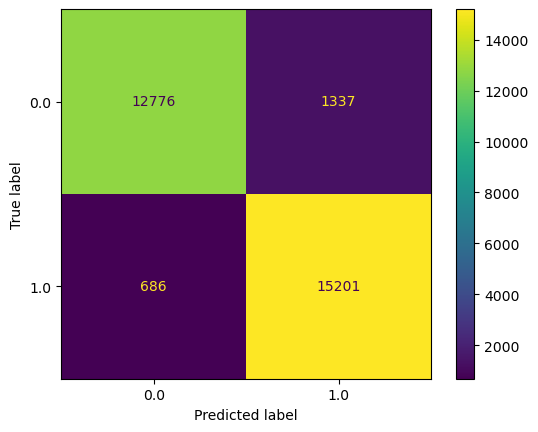

In [184]:
plot_confusion_matrix(gb_model,X_test, y_test) # Use `plot_confusion_matrix` to generate graphical output
plt.show()

In [260]:
joblib.dump(rf_model, 'rf_model.joblib')

['rf_model.joblib']

In [261]:
rf = joblib.load('rf_model.joblib')

In [262]:
val['predictions'] = rf.predict(X_val)

In [263]:
val.columns

Index(['VelInc_X', 'VelInc_Y', 'VelInc_Z', 'OriInc_w', 'OriInc_x', 'OriInc_y',
       'OriInc_z', 'Acc_X', 'Acc_Y', 'Acc_Z', 'Gyr_X', 'Gyr_Y', 'Gyr_Z',
       'Mag_X', 'Mag_Y', 'Mag_Z', 'Pressure', 'Roll', 'Pitch', 'Yaw', 'Sensor',
       'Activity Type', 'Activity Number', 'predictions'],
      dtype='object')

In [264]:
g = val.groupby('Activity Number')['predictions'].apply(list).reset_index(name='Activity')



In [265]:
joblib.dump(knn_model, 'knn_model.joblib')

['knn_model.joblib']

In [266]:
knn = joblib.load('knn_model.joblib')

In [267]:
val['predictions1'] = knn.predict(X_val)

In [268]:
val.columns

Index(['VelInc_X', 'VelInc_Y', 'VelInc_Z', 'OriInc_w', 'OriInc_x', 'OriInc_y',
       'OriInc_z', 'Acc_X', 'Acc_Y', 'Acc_Z', 'Gyr_X', 'Gyr_Y', 'Gyr_Z',
       'Mag_X', 'Mag_Y', 'Mag_Z', 'Pressure', 'Roll', 'Pitch', 'Yaw', 'Sensor',
       'Activity Type', 'Activity Number', 'predictions', 'predictions1'],
      dtype='object')

In [269]:
c = val.groupby('Activity Number')['predictions1'].apply(list).reset_index(name='Activity')

In [270]:
result_string = g.to_string(index=True)
print(result_string)

   Activity Number    Activity
0              802       [0.0]
1              805       [0.0]
2              806       [1.0]
3              808       [0.0]
4              809       [0.0]
5              908  [1.0, 1.0]
6              911       [1.0]
7              914       [1.0]
8              918       [1.0]


In [271]:
result_string1 = c.to_string(index=True)
print(result_string1)

   Activity Number    Activity
0              802       [0.0]
1              805       [0.0]
2              806       [1.0]
3              808       [0.0]
4              809       [0.0]
5              908  [0.0, 1.0]
6              911       [1.0]
7              914       [1.0]
8              918       [1.0]
